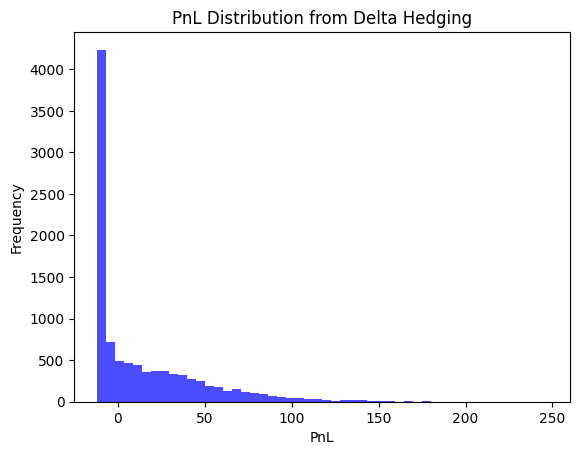

Expected PnL: 14.80
PnL Standard Deviation: 32.38


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Black-Scholes formula to calculate delta of a European option
def black_scholes_delta(S, K, T, r, sigma, option_type="call"):
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    if option_type == "call":
        return norm.cdf(d1)  # Call delta
    elif option_type == "put":
        return norm.cdf(d1) - 1  # Put delta

# Geometric Brownian Motion for underlying price simulation
def simulate_price(S0, T, r, sigma, steps, simulations):
    dt = T / steps
    prices = np.zeros((simulations, steps + 1))
    prices[:, 0] = S0
    for t in range(1, steps + 1):
        Z = np.random.standard_normal(simulations)
        prices[:, t] = prices[:, t - 1] * np.exp((r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z)
    return prices

# Delta hedging strategy simulation
def delta_hedging(S0, K, T, r, sigma, steps, simulations, option_type="call"):
    dt = T / steps
    prices = simulate_price(S0, T, r, sigma, steps, simulations)
    PnL = np.zeros(simulations)
    
    for sim in range(simulations):
        hedge = 0
        cash = 0
        for t in range(steps):
            current_time = (steps - t) * dt
            delta = black_scholes_delta(prices[sim, t], K, current_time, r, sigma, option_type)
            # Hedge adjustment
            hedge_change = delta - hedge
            hedge = delta
            cash -= hedge_change * prices[sim, t]
        
        # Final PnL from the hedging strategy (option payoff + cash - final hedge value)
        final_payoff = max(0, prices[sim, -1] - K) if option_type == "call" else max(0, K - prices[sim, -1])
        PnL[sim] = final_payoff + cash + hedge * prices[sim, -1]
    
    return PnL

# Simulation parameters
S0 = 100      # Initial underlying price
K = 100       # Strike price
T = 1         # Time to maturity (1 year)
r = 0.05      # Risk-free rate
sigma = 0.2   # Volatility
steps = 100   # Number of time steps
simulations = 10000  # Number of Monte Carlo simulations

# Run delta hedging simulation
PnL = delta_hedging(S0, K, T, r, sigma, steps, simulations)

# Plot histogram of PnL from delta hedging
plt.hist(PnL, bins=50, color='blue', alpha=0.7)
plt.title("PnL Distribution from Delta Hedging")
plt.xlabel("PnL")
plt.ylabel("Frequency")
plt.show()

# Print expected PnL and standard deviation
expected_pnl = np.mean(PnL)
pnl_std = np.std(PnL)
print(f"Expected PnL: {expected_pnl:.2f}")
print(f"PnL Standard Deviation: {pnl_std:.2f}")
